# Loading the model

In [1]:
# %%

# Lets import the packages
import torch
from torchvision import transforms
from LymphoMNIST.LymphoMNIST import LymphoMNIST

import torch.nn as nn
from torchvision import models
from torchsummary import summary


import time
from comet_ml import Experiment
import torch.optim as optim
from torchsummary import summary
from Project import Project
from poutyne.framework import Model
from poutyne.framework.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from callbacks import CometCallback
from logger import logging
import datetime, os

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# check LymphoMNIST virsion
import LymphoMNIST as info
print(f"LymphoMNIST v{info.__version__} @ {info.HOMEPAGE}")



# %%

from torch.utils.data import WeightedRandomSampler

def make_weights_for_balanced_classes(dataset, nclasses):
    # Count each class's occurrences in the dataset
    count = [0] * nclasses
    for _, label in dataset:
        count[label] += 1
    # Calculate the weight for each class based on their occurrences
    weight_per_class = [0.] * nclasses
    N = float(sum(count))
    for i in range(nclasses):
        weight_per_class[i] = N / float(count[i])
    # Assign weight to each sample based on its class
    weights = [weight_per_class[label] for _, label in dataset]
    return weights




# %%
from utils import device

import numpy as np
import torchvision.transforms as T
from imgaug import augmenters as iaa
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split



def get_dataloaders(
        train_ds,
        val_ds,
        split=(0.5, 0.5),
        batch_size=64,
        sampler=None, 
        num_workers=4,
        *args, **kwargs):
    """
    This function returns the train, val and test dataloaders.
    """
    lengths = [int(len(val_ds) * frac) for frac in split]
    lengths[1] += len(val_ds) - sum(lengths)  # Correct split length sum
    val_ds, test_ds = random_split(val_ds, lengths)

    # # now we want to split the val_ds in validation and test
    # lengths = np.array(split) * len(val_ds)
    # lengths = lengths.astype(int)
    # left = len(val_ds) - lengths.sum()
    # # we need to add the different due to float approx to int
    # lengths[-1] += left

    # val_ds, test_ds = random_split(val_ds, lengths.tolist())
    logging.info(f'Train samples={len(train_ds)}, Validation samples={len(val_ds)}, Test samples={len(test_ds)}')

    shuffle = False if sampler else True

    # train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, *args, **kwargs)
    # val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False, *args, **kwargs)
    # test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, *args, **kwargs)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False, sampler=sampler,  *args, **kwargs)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False, *args, **kwargs)
    test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, *args, **kwargs)

    return train_dl, val_dl, test_dl



class FilteredLymphoMNIST(Dataset):
    def __init__(self, original_dataset, labels_to_keep):
        self.original_dataset = original_dataset
        self.labels_to_keep = labels_to_keep
        self.label_map = {label: i for i, label in enumerate(labels_to_keep)}  # Map original labels to new labels
        self.indices = [i for i, (_, label) in enumerate(original_dataset) if label in labels_to_keep]

    def __getitem__(self, index):
        if index >= len(self.indices):
            raise IndexError("Index out of range")
        original_index = self.indices[index]
        image, label = self.original_dataset[original_index]
        # Remap the label
        return image, self.label_map[label.item()]

    def __len__(self):
        return len(self.indices)



class ConvertToRGB:
    """
    Convert 1-channel tensors to 3-channel tensors by duplicating the channel 3 times.
    """
    def __call__(self, tensor):
        # Check if the tensor is 1-channel (C, H, W) where C == 1
        if tensor.shape[0] == 1:
            # Duplicate the channel 3 times
            tensor = tensor.repeat(3, 1, 1)
        return tensor



im_size = 64

val_transform = T.Compose([
    T.Resize((im_size, im_size)),
    T.ToTensor(),
    T.Normalize([0.4819], [0.1484]),  # Adjusted for 1-channel
    ConvertToRGB()
])



#%%
# our hyperparameters
params = {
    'lr': 1e-6,
    'batch_size': 16,
    'epochs': 10000,
    'model': "teacher_final-balanced-transfer"
}


# Initialize dataset
original_train_ds = LymphoMNIST(root='./dataset', train=True, download=True, transform=val_transform, num_classes=3)
original_test_ds = LymphoMNIST(root='./dataset', train=False, download=True, transform=val_transform, num_classes=3)


# Specify labels to keep
labels_to_keep = [0, 2] # 0: B, 1: T4, 2: T8

# Initialize filtered dataset with labels to keep
train_ds = FilteredLymphoMNIST(original_train_ds, labels_to_keep)
test_ds= FilteredLymphoMNIST(original_test_ds, labels_to_keep)





# # Using the function with your dataset
# weights = make_weights_for_balanced_classes(train_ds, 2)
# sampler = WeightedRandomSampler(weights, len(weights))



# train_dl = DataLoader(train_ds, batch_size=params['batch_size'], sampler=sampler, *args, **kwargs)


# train_dl, val_dl, test_dl = get_dataloaders(train_ds,
#                                             test_ds,
#                                             split=(0.5, 0.5),
#                                             batch_size=params['batch_size'],
#                                             sampler=sampler,
#                                             num_workers=4
#                                            )
# Initialize dataloaders
train_dl, val_dl, test_dl = get_dataloaders(train_ds, test_ds, split=(0.5, 0.5), batch_size=params['batch_size'], num_workers=4)




LymphoMNIST v0.0.1 @ https://github.com/Khayrulbuet13/Lympho3-MNIST.git
Dataset already exists. Skipping download.
Dataset already exists. Skipping download.


2024-05-28 15:03:05,033 - [INFO] - Train samples=38400, Validation samples=4800, Test samples=4800


# Transfer0

In [20]:
# Load and modify a pre-trained ResNet50 model
resnet50 = models.resnet50(weights='IMAGENET1K_V1')
resnet50.fc = nn.Linear(resnet50.fc.in_features, 2)  # Adjust for the number of classes

model_weights_path = 'checkpoint/final_version/teacher_97_percent.pt'
# model_weights_path ='checkpoint/26 May 13:07-modelteacher_final-balanced-transfer.pt'
resnet50.load_state_dict(torch.load(model_weights_path, map_location=device))
cnn = resnet50.to(device)

# Summary
summary(cnn, (3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]           4,096
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,864
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
           Conv2d-11          [-1, 256, 16, 16]          16,384
      BatchNorm2d-12          [-1, 256, 16, 16]             512
           Conv2d-13          [-1, 256, 16, 16]          16,384
      BatchNorm2d-14          [-1, 256,

In [3]:
# print cnn model classification report
from sklearn.metrics import classification_report

cnn.eval()
y_true = []
y_pred = []
for inputs, labels in test_dl:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = cnn(inputs)
    _, predicted = torch.max(outputs, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1885
           1       0.96      0.89      0.93      2915

    accuracy                           0.91      4800
   macro avg       0.91      0.92      0.91      4800
weighted avg       0.92      0.91      0.91      4800



## ROC

In [21]:
cnn.eval()  # set the model to evaluation mode

# Variable for model predictions and true labels
y_pred = []
y_true = []

roc_data = {"test":[], 'val':[]}


with torch.no_grad():
    for image, target in test_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        # Get the probability of the positive class (class 1)
        pos_probs = probs[:, 1]
        y_pred.extend(pos_probs.cpu().numpy())  # Save predicted probabilities
        target = target.data.cpu().numpy()
        y_true.extend(target)  # Save actual labels
        
        


from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
roc_data['test'] = [fpr, tpr, roc_auc]



y_pred = []
y_true = []

with torch.no_grad():
    for image, target in val_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        # Get the probability of the positive class (class 1)
        pos_probs = probs[:, 1]
        y_pred.extend(pos_probs.cpu().numpy())  # Save predicted probabilities
        target = target.data.cpu().numpy()
        y_true.extend(target)  # Save actual labels
        
        



from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
roc_data['val'] = [fpr, tpr, roc_auc]
print(f'Area under the cureve: {roc_auc:.4f}')

Area under the cureve: 0.9665


# Transfer

In [22]:
# Load and modify a pre-trained ResNet50 model
resnet50 = models.resnet50(weights='IMAGENET1K_V1')
resnet50.fc = nn.Linear(resnet50.fc.in_features, 2)  # Adjust for the number of classes

# model_weights_path = 'checkpoint/26 May 13:07-modelteacher_final-balanced-transfer.pt'
model_weights_path = 'checkpoint/final_version/transfer.pt'
# model_weights_path ='checkpoint/26 May 13:07-modelteacher_final-balanced-transfer.pt'
resnet50.load_state_dict(torch.load(model_weights_path, map_location=device))
cnn = resnet50.to(device)

# Summary
summary(cnn, (3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]           4,096
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,864
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
           Conv2d-11          [-1, 256, 16, 16]          16,384
      BatchNorm2d-12          [-1, 256, 16, 16]             512
           Conv2d-13          [-1, 256, 16, 16]          16,384
      BatchNorm2d-14          [-1, 256,

In [11]:
# print cnn model classification report
from sklearn.metrics import classification_report

cnn.eval()
y_true = []
y_pred = []
for inputs, labels in test_dl:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = cnn(inputs)
    _, predicted = torch.max(outputs, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      1885
           1       0.95      0.97      0.96      2915

    accuracy                           0.95      4800
   macro avg       0.95      0.94      0.95      4800
weighted avg       0.95      0.95      0.95      4800



## ROC

In [23]:
cnn.eval()  # set the model to evaluation mode

# Variable for model predictions and true labels
y_pred = []
y_true = []

roc_data = {"test":[], 'val':[]}


with torch.no_grad():
    for image, target in test_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        # Get the probability of the positive class (class 1)
        pos_probs = probs[:, 1]
        y_pred.extend(pos_probs.cpu().numpy())  # Save predicted probabilities
        target = target.data.cpu().numpy()
        y_true.extend(target)  # Save actual labels
        
        


from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
roc_data['test'] = [fpr, tpr, roc_auc]



y_pred = []
y_true = []

with torch.no_grad():
    for image, target in val_dl:
        image, target = image.to(device), target.to(device)
        outputs = cnn(image)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        # Get the probability of the positive class (class 1)
        pos_probs = probs[:, 1]
        y_pred.extend(pos_probs.cpu().numpy())  # Save predicted probabilities
        target = target.data.cpu().numpy()
        y_true.extend(target)  # Save actual labels
        
        



from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
roc_data['val'] = [fpr, tpr, roc_auc]
print(f'Area under the cureve: {roc_auc:.4f}')

Area under the cureve: 0.9895


# compare all results

In [56]:
# graph values
model_accuracy = [96, 94, 91, 95]
model_labels = ['Teacher', 'Student', 'Transfer0', 'Transfer' ]
model_precision = [96, 94, 92, 95]
model_recall= [96, 94, 91, 95]
model_f1_score = [96, 94, 91, 95]
model_auroc = [100, 99, 96.7, 98.9 ]

#### pltting the bar chart

#### accuracy

4


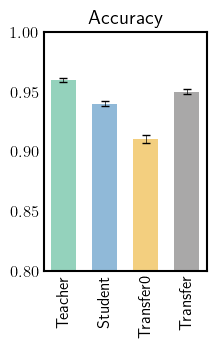

In [68]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

X_vals = np.array(model_accuracy)*.01
std_errors = np.array([ 0.157, 0.221, 0.342, .236])*.01


colors4 = ['#2ba77b', '#2274b2', '#e9a001', '#545253']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(2.1, 3.1), dpi = 100)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

print(len(bars))
for i, bar in enumerate(bars):
    bar.set_color(colors4[i])

# ax.set_ylabel('Precission (\%)')
ax.title.set_text('Accuracy')  
plt.yticks( fontsize = 12)
plt.xticks(rotation=90, fontsize = 12)
plt.ylim([.8, 1])

image_name = "./paper_viz/transfer/accuracy"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')


### precision

4


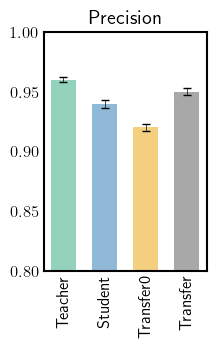

In [67]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

X_vals = np.array(model_precision)*.01
std_errors = np.array([0.221, 0.342, 0.266, 0.314])*.01


colors4 = ['#2ba77b', '#2274b2', '#e9a001', '#545253']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(2.1, 3.1), dpi = 100)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

print(len(bars))
for i, bar in enumerate(bars):
    bar.set_color(colors4[i])

# ax.set_ylabel('Precission (\%)')
ax.title.set_text('Precision')  
plt.yticks( fontsize = 12)
plt.xticks(rotation=90, fontsize = 12)
plt.ylim([.8, 1])

image_name = "./paper_viz/transfer/precision"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')


#### recall

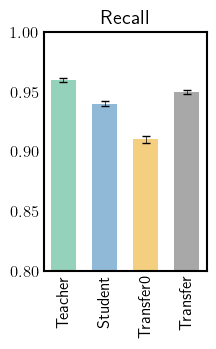

In [62]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50


X_vals = np.array(model_recall)*.01
std_errors = np.array([0.166, 0.177, 0.32,  0.157])*.01

colors4 = ['#2ba77b', '#2274b2', '#e9a001', '#545253']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(2.1, 3.1), dpi = 100)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, 
              edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors4[i])

ax.title.set_text('Recall') 
plt.yticks( fontsize = 12)
plt.xticks(rotation=90, fontsize = 12)
plt.ylim([.80, 1])

image_name = "./paper_viz/transfer/recall"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')

#### F1 -score

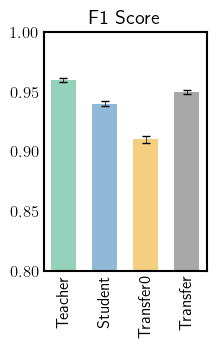

In [63]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

X_vals = np.array(model_f1_score)*.01
std_errors = np.array([0.166, 0.177, 0.32,  0.157])*.01


colors4 = ['#2ba77b', '#2274b2', '#e9a001', '#545253']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(2.1, 3.1), dpi = 100)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, 
              edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors4[i])

ax.title.set_text('F1 Score') 
plt.yticks( fontsize = 12)
plt.xticks(rotation=90, fontsize = 12)
plt.ylim([.80, 1])


image_name = "./paper_viz/transfer/f1_score"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')

#### AUROC

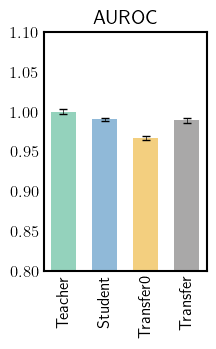

In [64]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

X_vals = np.array(model_auroc)*.01
std_errors = np.array([ 0.32,  0.157, 0.221, 0.342])*.01


colors4 = ['#2ba77b', '#2274b2', '#e9a001', '#545253']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(2.1, 3.1), dpi = 100)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, 
              edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors4[i])

ax.title.set_text('AUROC') 
# plt.yticks( fontsize = 12)
plt.xticks(rotation=90)
plt.ylim([.80, 1.1])


image_name = "./paper_viz/transfer/auroc"
plt.savefig(image_name+ '.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=1200, bbox_inches='tight')